# Model Comparison — COVID+ vs COVID−

Dieses Notebook erzeugt **eine** Vergleichsgrafik:

- **Balken** = COVID+ Werte (verstorben)
- **Schwarze Linien** = COVID− Werte (verstorben), über dem jeweiligen Balken

**So benutzt du es:**
1. Trage in **Zelle 1** deine Werte ein (`means_pos` und `means_neg`).
   - Eine **Zeile pro Modell**, eine **Spalte pro Metrik** (Reihenfolge wie in `metrics`).
   - Fehlende Werte als `np.nan` eintragen → dann erscheint automatisch ein `n/a`-Hinweis (kein Balken / keine Linie).
2. Führe **Zelle 1** und dann **Zelle 2** aus.
3. Die Grafik wird angezeigt und als `model_comparison_POS_vs_NEG.png` gespeichert.

Standardabweichungen werden nicht mehr verwendet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
models  = ['Logistic Regression', 'Random Forest', 'SVM', 'K-Nearest Neighbors']

# COVID+  (verstorben)  ->  BALKEN
means_pos = np.array([
    [0.67, 0.63, 0.74, 0.68, 0.73],   # Logistic Regression
    [0.68, 0.63, 0.77, 0.69, 0.74],   # Random Forest
    [0.68, 0.64, 0.72, 0.68, 0.68],   # SVM
    [0.65, 0.62, 0.66, 0.64, 0.70],   # K-Nearest Neighbors
])

# COVID-  (verstorben)  ->  LINIE
means_neg = np.array([
    [0.64, 0.30, 0.71, 0.42, 0.72],   # Logistic Regression
    [0.64, 0.30, 0.74, 0.43, 0.73],   # Random Forest
    [0.64, 0.30, 0.71, 0.42, 0.64],   # SVM
    [0.75, 0.27, 0.22, 0.24, 0.65],   # K-Nearest Neighbors
])

# Balkenfarben (eine pro Modell)
colors = ['#9ec5e8', '#a8d8b9', '#f4c28a', '#f2a6a6']


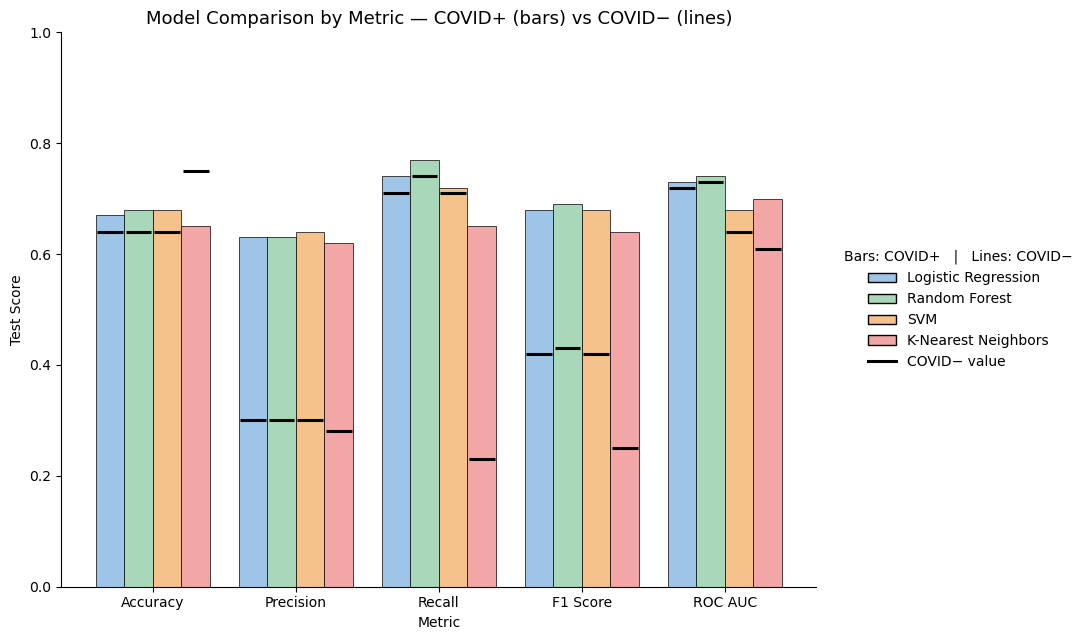

In [4]:
# ============================================================
#  PLOT  (nichts aendern noetig)
# ============================================================
x         = np.arange(len(metrics))
n_models  = len(models)
bar_width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(11, 6.5))

# --- Balken = COVID+ ---
for i in range(n_models):
    offset = (i - (n_models - 1) / 2) * bar_width
    ax.bar(x + offset, means_pos[i], bar_width,
           color=colors[i], edgecolor='black', linewidth=0.5, zorder=2)

# --- Linien = COVID- (kurzes horizontales Segment ueber jedem Balken) ---
line_w  = bar_width * 0.9
missing = []   # merkt sich (Modell, Metrik) ohne COVID--Wert
for i in range(n_models):
    offset = (i - (n_models - 1) / 2) * bar_width
    for j in range(len(metrics)):
        xc  = x[j] + offset
        val = means_neg[i, j]
        if np.isnan(val):
            if not np.isnan(means_pos[i, j]):          # nur markieren, wo es einen Balken gibt
                missing.append((models[i], metrics[j]))
                ax.text(xc, 0.02, 'n/a', rotation=90, ha='center', va='bottom',
                        fontsize=7, color='#888888')
            continue
        ax.hlines(val, xc - line_w / 2, xc + line_w / 2,
                  color='black', linewidth=2.2, zorder=3)

# --- Achsen / Titel ---
ax.set_title('Model Comparison by Metric \u2014 COVID+ (bars) vs COVID\u2212 (lines)', fontsize=13)
ax.set_xlabel('Metric')
ax.set_ylabel('Test Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.set_axisbelow(True)
ax.yaxis.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# --- Legende: Modelle (Balken) + COVID--Linie ---
handles = [Patch(facecolor=colors[i], edgecolor='black', label=models[i])
           for i in range(n_models)]
handles.append(Line2D([0], [0], color='black', linewidth=2.2, label='COVID\u2212 value'))
ax.legend(handles=handles, title='Bars: COVID+   |   Lines: COVID\u2212',
          loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# --- automatischer Hinweis zu fehlenden COVID--Werten ---
if missing:
    note = 'COVID\u2212 nicht verfuegbar: ' + ', '.join(f'{m} ({me})' for m, me in missing)
    fig.text(0.99, 0.005, note, ha='right', va='bottom', fontsize=7, color='#888888')

plt.tight_layout()
plt.savefig('model_comparison_POS_vs_NEG.png', dpi=300, bbox_inches='tight')
plt.show()
